## Yellow-legged hornet model

11 - Patch construction

12 - Grid Search

13 - PSO

**14 - Simulation**

15 - Map

**Spatial Division 1**

 Region 1: France

 Region 2: others

Spatial Division 2

 Region 1: France _+ Portugal

 Region 2: others


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

In [ ]:
## ONLY PARTITION 1

patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_patch_attributes_V6.csv")

D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_D_shortest_global_V6.npy")

In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'A_i', 'occyear1',
       'occyear2', 'region'],
      dtype='object')

In [ ]:
O_j = patch_df["occyear2"].to_numpy(dtype=float)

obsyear1 = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()
region = patch_df["region"].to_numpy()

In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", int(obsyear1.sum()))
print("occupied year2 =", int(obsyear2.sum()))

n patches = 2567
occupied year1 = 866
occupied year2 = 794


In [ ]:
# Grid Search - Partition 1
gs_d1_params = {
    "alpha_reg1": 1.7500,
    "y_reg1": 1.1000,
    "e_reg1": 0.1500,
    "x_reg1": 9.0000,
    "alpha_reg2": 0.1500,
    "y_reg2": 70.0000,
    "e_reg2": 0.1000,
    "x_reg2": 0.1000
}


# PSO - Partition 1
pso_d1_params = {
    "alpha_reg1": 0.7503,
    "y_reg1": 35.9424,
    "e_reg1": 5.5152,
    "x_reg1": 4.1031,
    "alpha_reg2": 0.1131,
    "y_reg2": 38.5065,
    "e_reg2": 8.8711,
    "x_reg2": 0.2721
}



In [ ]:
def run_ifm_simulation(alpha_reg1, y_reg1, e_reg1, x_reg1,
                     alpha_reg2, y_reg2, e_reg2, x_reg2,
                     n_steps):

    region = patch_df["region"].to_numpy()

    alpha_i = np.where(region == 1, alpha_reg1, alpha_reg2)
    y_i = np.where(region == 1, y_reg1, y_reg2)
    e_i = np.where(region == 1, e_reg1, e_reg2)
    x_i = np.where(region == 1, x_reg1, x_reg2)

    K_ij = np.exp(-alpha_i[:, None] * D_ij)
    np.fill_diagonal(K_ij, 0)

    E_i = np.minimum(e_i / (A_j ** x_i), 1)

    p_current = patch_df["occyear2"].to_numpy(dtype=float)

    simulation_results = []

    for step in range(1, n_steps + 1):

        S_i = K_ij @ (p_current * A_j)
        C_i = S_i**2 / (S_i**2 + y_i**2)


        p_next = C_i*(1 - p_current)  + (1 - (1 - C_i) * E_i)*p_current


        simulation_results.append((step, E_i.copy(),  S_i.copy(), C_i.copy(), p_next.copy()))

        p_current = p_next.copy()

    return simulation_results



---

## simulation

In [ ]:
# 1 GS Division 1 deterministic simulation

n_steps = 100

region_array = patch_df["region"].to_numpy()
patch_ids = patch_df["patch_id"].to_numpy()


map_steps = {
    step: 2018 + step * 2
    for step in range(1, n_steps + 1, 5)
}


simulation_results_d1_gs_deter = run_ifm_simulation(
    **gs_d1_params,
    n_steps=n_steps
)


all_results_d1_gs_deter = []
patch_results_d1_gs_deter = []


for step, E_i, S_i, C_i, p_next in simulation_results_d1_gs_deter:

    # region
    for region in [1, 2]:

        mask = region_array == region

        all_results_d1_gs_deter.append({
            "step": step,
            "region": region,
            "mean_E": E_i[mask].mean(),
            "mean_S": S_i[mask].mean(),
            "mean_C": C_i[mask].mean(),
            "mean_occupancy": p_next[mask].mean(),
            "n_pred": (p_next[mask] > 0.5).sum()
        })

    # patch
    if step in map_steps:

        for i in range(len(patch_df)):

            patch_results_d1_gs_deter.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_ids[i],
                "region": region_array[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })


# region
summary_d1_gs_deter = pd.DataFrame(
    all_results_d1_gs_deter
)

# patch
patch_results_d1_gs_deter = pd.DataFrame(
    patch_results_d1_gs_deter
)


print(summary_d1_gs_deter)

print(patch_results_d1_gs_deter.head())

     step  region    mean_E        mean_S        mean_C  mean_occupancy  \
0       1       1  0.002145  2.654471e-09  2.150845e-15        0.336707   
1       1       2  0.055444  2.803902e+01  1.817683e-01        0.291119   
2       2       1  0.002145  2.654472e-09  2.150845e-15        0.336707   
3       2       2  0.055444  2.999998e+01  1.944922e-01        0.311039   
4       3       1  0.002145  2.654472e-09  2.150845e-15        0.336707   
..    ...     ...       ...           ...           ...             ...   
195    98       2  0.055444  9.833136e+01  6.532746e-01        0.968933   
196    99       1  0.002145  2.654482e-09  2.150845e-15        0.336707   
197    99       2  0.055444  9.833137e+01  6.532747e-01        0.968933   
198   100       1  0.002145  2.654482e-09  2.150845e-15        0.336707   
199   100       2  0.055444  9.833138e+01  6.532748e-01        0.968934   

     n_pred  
0       499  
1       308  
2       499  
3       331  
4       499  
..      ...  
1

In [ ]:
print(
    summary_d1_gs_deter[
        [
            "step",
            "region",
            "mean_E",
            "mean_S",
            "mean_C",
            "mean_occupancy",
            "n_pred"
        ]
    ]
)

     step  region    mean_E        mean_S        mean_C  mean_occupancy  \
0       1       1  0.002145  2.654471e-09  2.150845e-15        0.336707   
1       1       2  0.055444  2.803902e+01  1.817683e-01        0.291119   
2       2       1  0.002145  2.654472e-09  2.150845e-15        0.336707   
3       2       2  0.055444  2.999998e+01  1.944922e-01        0.311039   
4       3       1  0.002145  2.654472e-09  2.150845e-15        0.336707   
..    ...     ...       ...           ...           ...             ...   
195    98       2  0.055444  9.833136e+01  6.532746e-01        0.968933   
196    99       1  0.002145  2.654482e-09  2.150845e-15        0.336707   
197    99       2  0.055444  9.833137e+01  6.532747e-01        0.968933   
198   100       1  0.002145  2.654482e-09  2.150845e-15        0.336707   
199   100       2  0.055444  9.833138e+01  6.532748e-01        0.968934   

     n_pred  
0       499  
1       308  
2       499  
3       331  
4       499  
..      ...  
1

In [ ]:
summary_d1_gs_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d1_gs_deter.csv",
    index=False
)

patch_results_d1_gs_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d1_gs_deter.csv",
    index=False
)

In [ ]:
region_array = patch_df["region"].to_numpy()

mean_all_d1_gs_deter = []

for step, E_i, S_i, C_i, p_next in simulation_results_d1_gs_deter:

    mask_r1 = region_array == 1
    mask_r2 = region_array == 2

    mean_all_d1_gs_deter.append({
        "step": step,
        "year": 2018 + step * 2,

        # all patches
        "mean_S_all": S_i.mean(),
        "mean_C_all": C_i.mean(),
        "mean_p_all": p_next.mean(),

        # Region 1
        "mean_S_r1": S_i[mask_r1].mean(),
        "mean_C_r1": C_i[mask_r1].mean(),
        "mean_p_r1": p_next[mask_r1].mean(),

        # Region 2
        "mean_S_r2": S_i[mask_r2].mean(),
        "mean_C_r2": C_i[mask_r2].mean(),
        "mean_p_r2": p_next[mask_r2].mean()
    })


mean_all_d1_gs_deter = pd.DataFrame(
    mean_all_d1_gs_deter
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(mean_all_d1_gs_deter)

    step  year  mean_S_all  mean_C_all  mean_p_all     mean_S_r1  \
0      1  2020   11.851318    0.076828    0.317438  2.654471e-09   
1      2  2022   12.680165    0.082206    0.325858  2.654472e-09   
2      3  2024   13.559956    0.088039    0.334792  2.654472e-09   
3      4  2026   14.503781    0.094387    0.344204  2.654472e-09   
4      5  2028   15.501790    0.101114    0.353943  2.654473e-09   
5      6  2030   16.535365    0.108051    0.363866  2.654473e-09   
6      7  2032   17.587394    0.115099    0.373917  2.654473e-09   
7      8  2034   18.650126    0.122238    0.384095  2.654473e-09   
8      9  2036   19.721719    0.129448    0.394361  2.654474e-09   
9     10  2038   20.798038    0.136678    0.404645  2.654474e-09   
10    11  2040   21.872831    0.143882    0.414896  2.654474e-09   
11    12  2042   22.942186    0.151047    0.425091  2.654475e-09   
12    13  2044   24.004104    0.158169    0.435221  2.654475e-09   
13    14  2046   25.056826    0.165237    0.4452



---



In [ ]:
# 2 PSO Division 1 - deterministic simulation

n_steps = 100

region_array = patch_df["region"].to_numpy()
patch_ids = patch_df["patch_id"].to_numpy()

map_steps = {
    step: 2018 + step * 2
    for step in range(1, n_steps + 1, 5)
}

simulation_results_d1_pso_deter = run_ifm_simulation(
    **pso_d1_params,
    n_steps=n_steps
)


all_results_d1_pso_deter = []
patch_results_d1_pso_deter = []


for step, E_i, S_i, C_i, p_next in simulation_results_d1_pso_deter:

    # Regional results
    for region in [1, 2]:

        mask = region_array == region

        all_results_d1_pso_deter.append({
            "step": step,
            "region": region,
            "mean_E": E_i[mask].mean(),
            "mean_S": S_i[mask].mean(),
            "mean_C": C_i[mask].mean(),
            "mean_occupancy": p_next[mask].mean(),
            "n_pred": (p_next[mask] > 0.5).sum()
        })

    # Patch-level results -- 2020, 2030, 2040, 2050
    if step in map_steps:

        for i in range(len(patch_df)):

            patch_results_d1_pso_deter.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_ids[i],
                "region": region_array[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })


# region
summary_d1_pso_deter = pd.DataFrame(
    all_results_d1_pso_deter
)

# patch
patch_results_d1_pso_deter = pd.DataFrame(
    patch_results_d1_pso_deter
)


print(summary_d1_pso_deter)

print(patch_results_d1_pso_deter.head())

     step  region  mean_E      mean_S        mean_C  mean_occupancy  n_pred
0       1       1  0.0027    0.000624  1.025815e-08        0.336707     499
1       1       2  1.0000   66.890028  3.582349e-01        0.358235     414
2       2       1  0.0027    0.000625  1.025827e-08        0.336707     499
3       2       2  1.0000   88.653856  4.663277e-01        0.466328     525
4       3       1  0.0027    0.000626  1.025850e-08        0.336707     499
5       3       2  1.0000  116.516208  5.784220e-01        0.578422     651
6       4       1  0.0027    0.000626  1.025865e-08        0.336707     499
7       4       2  1.0000  144.919412  6.804680e-01        0.680468     765
8       5       1  0.0027    0.000627  1.025872e-08        0.336707     499
9       5       2  1.0000  170.244400  7.645045e-01        0.764504     863
10      6       1  0.0027    0.000627  1.025878e-08        0.336706     499
11      6       2  1.0000  190.993359  8.327958e-01        0.832796     938
12      7   

In [ ]:
summary_d1_pso_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d1_pso_deter.csv",
    index=False
)

patch_results_d1_pso_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d1_pso_deter.csv",
    index=False
)

In [ ]:
%whos

Variable                          Type         Data/Info
--------------------------------------------------------
A_j                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
C_i                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
D_ij                              ndarray      2567x2567: 6589489 elems, type `float64`, 52715912 bytes (50.27381134033203 Mb)
E_i                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
Image                             type         <class 'IPython.core.display.Image'>
O_j                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
S_i                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
all_results_d1_gs_deter           list         n=200
all_results_d1_pso_deter          list         n=200
drive                             module       <module 'google.colab.dri<...>s/google/colab/drive.py'>
g

In [ ]:
print(summary_d1_gs_deter.columns)
print(summary_d1_pso_deter.columns)

Index(['step', 'region', 'mean_E', 'mean_S', 'mean_C', 'mean_occupancy',
       'n_pred'],
      dtype='object')
Index(['step', 'region', 'mean_E', 'mean_S', 'mean_C', 'mean_occupancy',
       'n_pred'],
      dtype='object')


In [ ]:
print("GS")
print(
    summary_d1_gs_deter
    .groupby("region")["mean_E"]
    .first()
)

print("\nPSO")
print(
    summary_d1_pso_deter
    .groupby("region")["mean_E"]
    .first()
)

GS
region
1    0.002145
2    0.055444
Name: mean_E, dtype: float64

PSO
region
1    0.0027
2    1.0000
Name: mean_E, dtype: float64


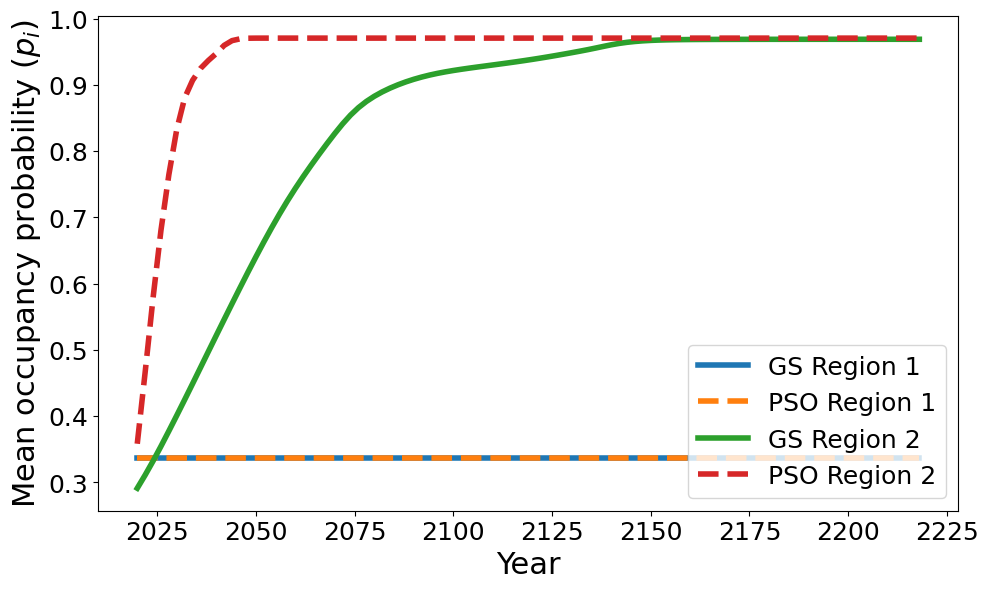

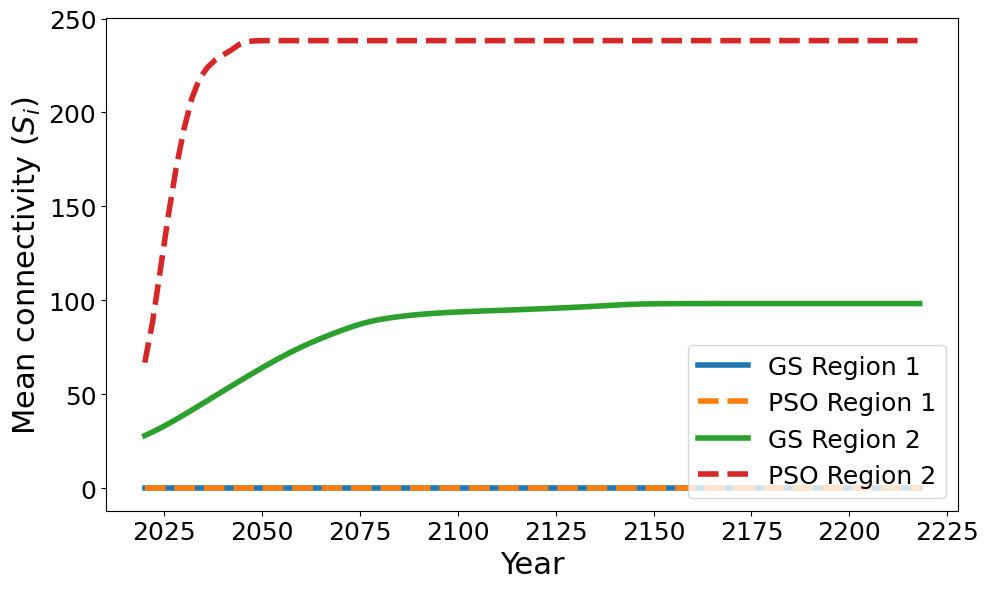

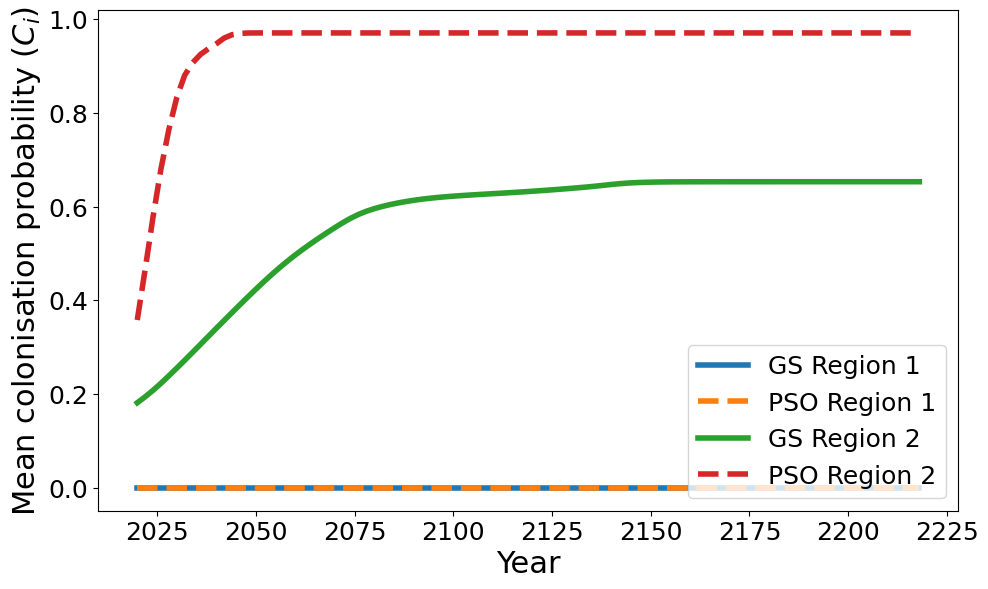

In [ ]:
import matplotlib.pyplot as plt

plot_vars = {
    "mean_occupancy": r"Mean occupancy probability ($p_i$)",
    "mean_S": r"Mean connectivity ($S_i$)",
    "mean_C": r"Mean colonisation probability ($C_i$)"
}

for var, ylabel in plot_vars.items():

    plt.figure(figsize=(10, 6))

    for region in [1, 2]:

        df_gs = summary_d1_gs_deter[
            summary_d1_gs_deter["region"] == region
        ]

        df_pso = summary_d1_pso_deter[
            summary_d1_pso_deter["region"] == region
        ]

        # GS
        plt.plot(
            2018 + df_gs["step"] * 2,
            df_gs[var],
            linewidth=4,
            linestyle="-",
            label=f"GS Region {region}"
        )

        # PSO
        plt.plot(
            2018 + df_pso["step"] * 2,
            df_pso[var],
            linewidth=4,
            linestyle="--",
            label=f"PSO Region {region}"
        )

    plt.xlabel("Year", fontsize=22)
    plt.ylabel(ylabel, fontsize=22)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.legend(
        fontsize=18,
        loc="lower right"
    )

    plt.tight_layout()
    plt.show()

# Management case

In [ ]:
print(gs_d1_params)

{'alpha_reg1': 1.75, 'y_reg1': 1.1, 'e_reg1': 0.15, 'x_reg1': 9.0, 'alpha_reg2': 0.15, 'y_reg2': 70.0, 'e_reg2': 0.1, 'x_reg2': 0.1}


In [ ]:
gs_r1_only_params = gs_d1_params.copy()

gs_r1_only_params["alpha_reg2"] = gs_r1_only_params["alpha_reg1"]
gs_r1_only_params["y_reg2"] = gs_r1_only_params["y_reg1"]
gs_r1_only_params["e_reg2"] = gs_r1_only_params["e_reg1"]
gs_r1_only_params["x_reg2"] = gs_r1_only_params["x_reg1"]

print(gs_r1_only_params)

{'alpha_reg1': 1.75, 'y_reg1': 1.1, 'e_reg1': 0.15, 'x_reg1': 9.0, 'alpha_reg2': 1.75, 'y_reg2': 1.1, 'e_reg2': 0.15, 'x_reg2': 9.0}


In [ ]:
simulation_results_d1_gs_r1_only_deter = run_ifm_simulation(
    **gs_r1_only_params,
    n_steps=n_steps
)

In [ ]:
# GS Region 1 parameters only - deterministic simulation

n_steps = 100

region_array = patch_df["region"].to_numpy()
patch_ids = patch_df["patch_id"].to_numpy()

map_steps = {
    step: 2018 + step * 2
    for step in range(1, n_steps + 1, 5)
}

simulation_results_d1_gs_r1_only_deter = run_ifm_simulation(
    **gs_r1_only_params,
    n_steps=n_steps
)

all_results_d1_gs_r1_only_deter = []
patch_results_d1_gs_r1_only_deter = []

for step, E_i, S_i, C_i, p_next in simulation_results_d1_gs_r1_only_deter:

    # region
    for region in [1, 2]:
        mask = region_array == region

        all_results_d1_gs_r1_only_deter.append({
            "step": step,
            "region": region,
            "mean_E": E_i[mask].mean(),
            "mean_S": S_i[mask].mean(),
            "mean_C": C_i[mask].mean(),
            "mean_occupancy": p_next[mask].mean(),
            "n_pred": (p_next[mask] > 0.5).sum()
        })

    # patch-level results
    if step in map_steps:
        for i in range(len(patch_df)):

            patch_results_d1_gs_r1_only_deter.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_ids[i],
                "region": region_array[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })

# region-level summary
summary_d1_gs_r1_only_deter = pd.DataFrame(
    all_results_d1_gs_r1_only_deter
)

# patch-level results
patch_results_d1_gs_r1_only_deter = pd.DataFrame(
    patch_results_d1_gs_r1_only_deter
)

print(summary_d1_gs_r1_only_deter)

print(
    patch_results_d1_gs_r1_only_deter.head()
)

     step  region        mean_E        mean_S        mean_C  mean_occupancy  \
0       1       1  2.144908e-03  2.654471e-09  2.150845e-15        0.336707   
1       1       2  5.352941e-10  1.121614e-09  1.085629e-16        0.271889   
2       2       1  2.144908e-03  2.654471e-09  2.150845e-15        0.336707   
3       2       2  5.352941e-10  1.121614e-09  1.085629e-16        0.271889   
4       3       1  2.144908e-03  2.654471e-09  2.150845e-15        0.336707   
5       3       2  5.352941e-10  1.121614e-09  1.085629e-16        0.271889   
6       4       1  2.144908e-03  2.654471e-09  2.150845e-15        0.336707   
7       4       2  5.352941e-10  1.121614e-09  1.085629e-16        0.271889   
8       5       1  2.144908e-03  2.654471e-09  2.150845e-15        0.336707   
9       5       2  5.352941e-10  1.121614e-09  1.085629e-16        0.271889   
10      6       1  2.144908e-03  2.654471e-09  2.150845e-15        0.336707   
11      6       2  5.352941e-10  1.121614e-09  1.085

In [ ]:
summary_d1_gs_r1_only_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d1_gs_r1_only_deter.csv",
    index=False
)

patch_results_d1_gs_r1_only_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d1_gs_r1_only_deter.csv",
    index=False
)

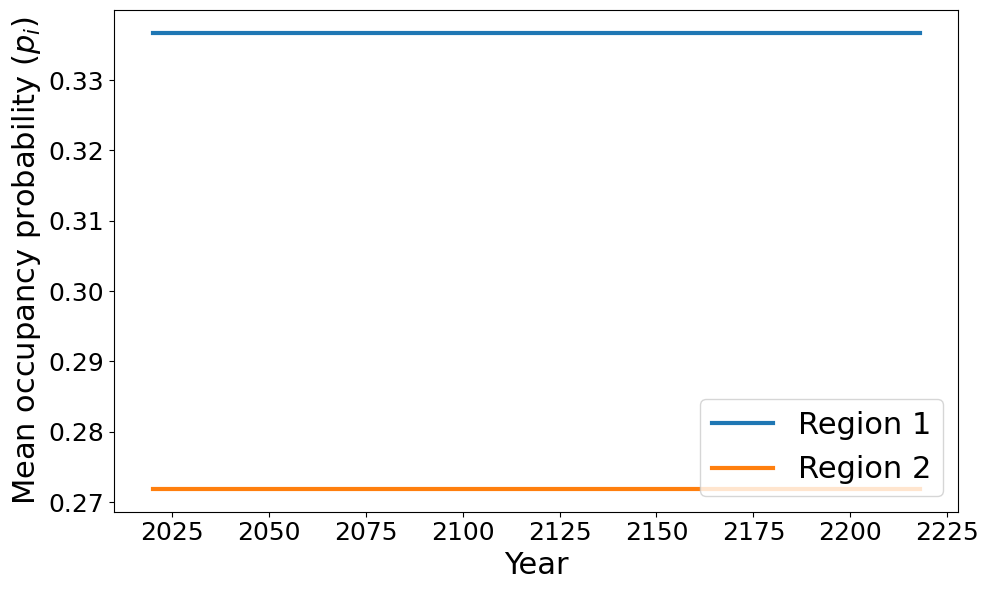

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d1_gs_r1_only_deter[
        summary_d1_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()

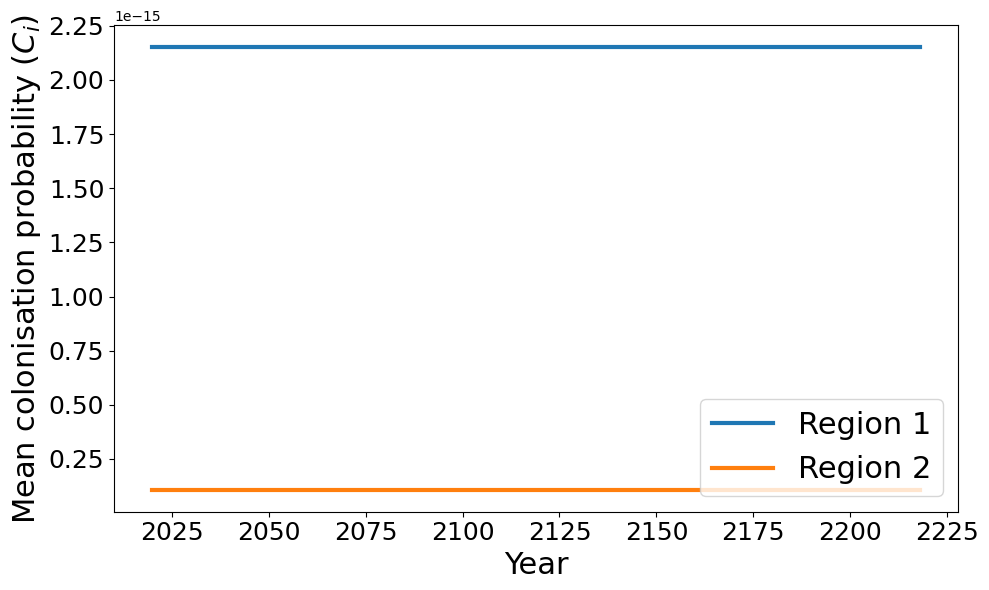

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d1_gs_r1_only_deter[
        summary_d1_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean colonisation probability ($C_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [ ]:
%whos

Variable                                 Type         Data/Info
---------------------------------------------------------------
A_j                                      ndarray      2567: 2567 elems, type `float64`, 20536 bytes
C_i                                      ndarray      2567: 2567 elems, type `float64`, 20536 bytes
D_ij                                     ndarray      2567x2567: 6589489 elems, type `float64`, 52715912 bytes (50.27381134033203 Mb)
E_i                                      ndarray      2567: 2567 elems, type `float64`, 20536 bytes
Image                                    type         <class 'IPython.core.display.Image'>
O_j                                      ndarray      2567: 2567 elems, type `float64`, 20536 bytes
S_i                                      ndarray      2567: 2567 elems, type `float64`, 20536 bytes
all_results_d1_gs_deter                  list         n=200
all_results_d1_gs_r1_only_deter          list         n=200
all_results_d1_pso_deter   